<a href="https://colab.research.google.com/github/athitthiyan/Learning_Gen_AI/blob/main/milestone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Setup — run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

In [2]:
#1.Load
df = sns.load_dataset('taxis')
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [3]:
#2.Clean
df = df.dropna()
df['trip_type'] = pd.cut(
    df['distance'],
    bins=[0, 2, 5, 15, 100],
    labels=['Short', 'Medium', 'Long', 'Very Long']
)
print(df[['distance', 'trip_type']].head())

   distance trip_type
0      1.60     Short
1      0.79     Short
2      1.37     Short
3      7.70      Long
4      2.16    Medium


In [4]:
#3.GroupBy
avg_fare = np.mean(df['fare'])
max_distance = np.max(df['distance'])
print("Average Fare: ", avg_fare)
print("Max Distance: ", max_distance)
payment_status = df.groupby('payment')['fare'].mean()
print(payment_status)

Average Fare:  12.887930925721495
Max Distance:  36.7
payment
cash           11.259053
credit card    13.531098
Name: fare, dtype: float64


/tmp/ipykernel_2159/2519407567.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


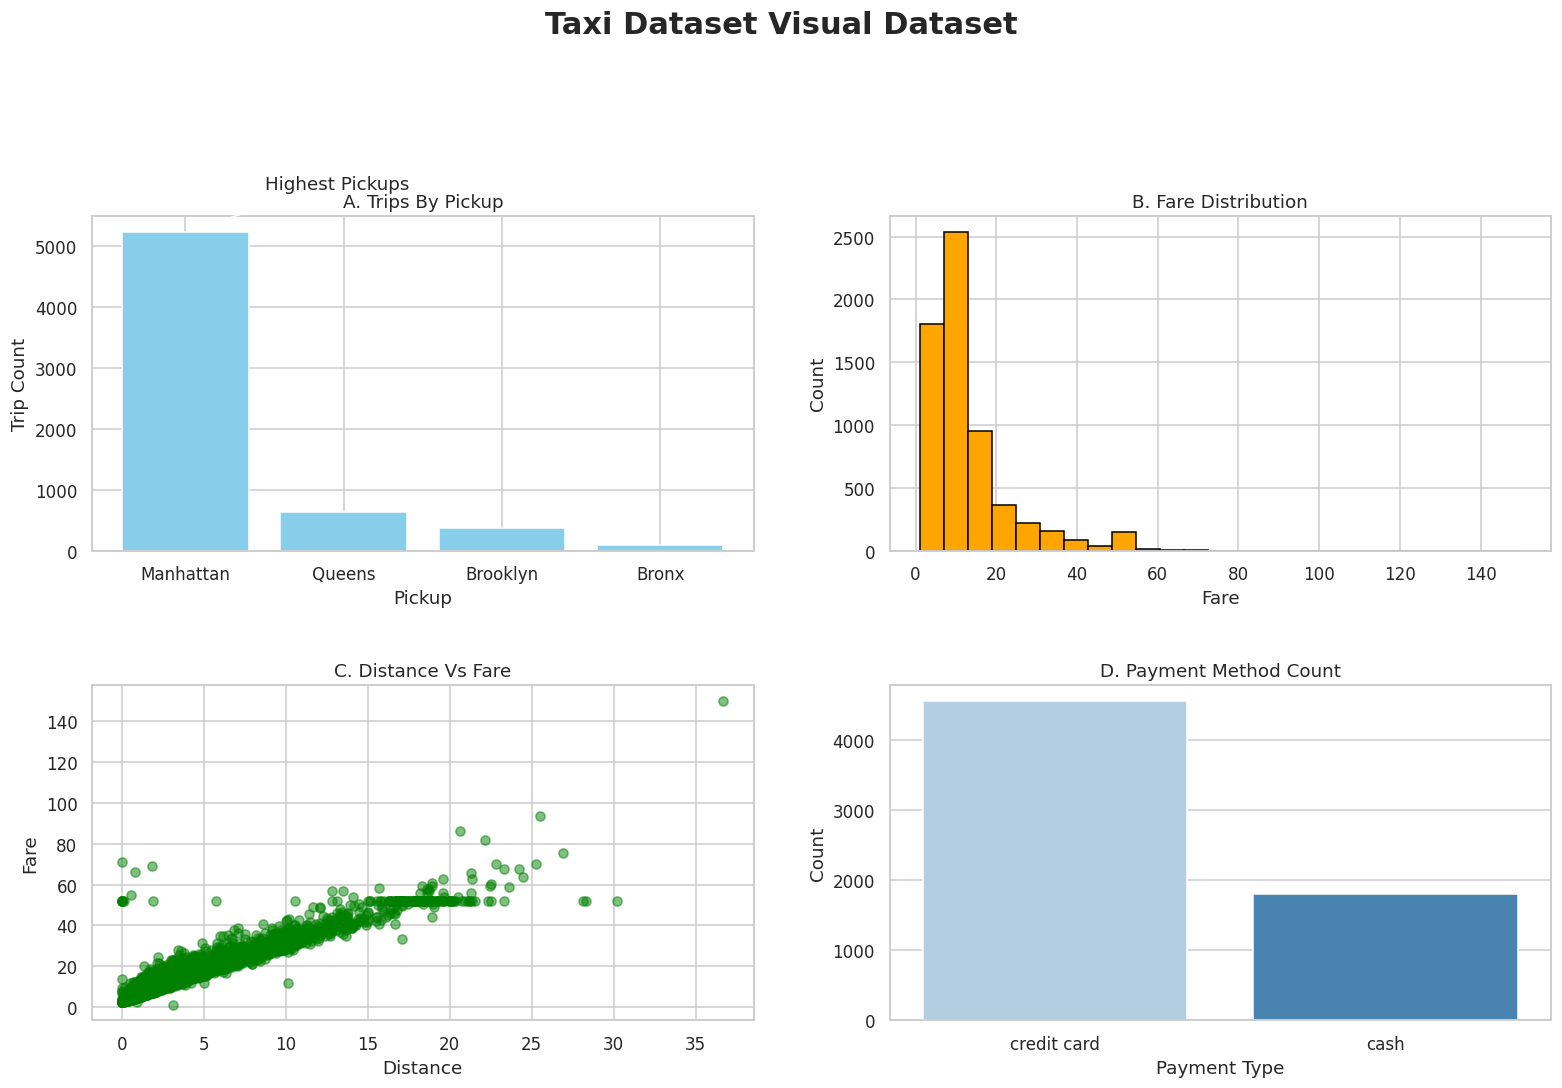

In [5]:
#4.Charts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
  'Taxi Dataset Visual Dataset',
  fontsize=20,
  fontweight='bold',
  y=1.02
)

#4.1 Bar Chart
ax = axes[0, 0]
pickup_counts = df['pickup_borough'].value_counts()
ax.bar(
  pickup_counts.index,
  pickup_counts.values,
  color='skyblue'
)
ax.set_title('A. Trips By Pickup')
ax.set_xlabel('Pickup')
ax.set_ylabel('Trip Count')

ax.annotate(
  'Highest Pickups',
  xy=(0, pickup_counts.values[0]),
  xytext=(0.5, pickup_counts.values[0] + 700),
  arrowprops=dict(arrowstyle='->')
)

#4.2 Histogram
ax = axes[0, 1]
ax.hist(
  df['fare'],
  bins=25,
  color='orange',
  edgecolor='black'
)
ax.set_title('B. Fare Distribution')
ax.set_xlabel('Fare')
ax.set_ylabel('Count')

#4.3 Scatter Plot
ax = axes[1, 0]
ax.scatter(
  df['distance'],
  df['fare'],
  alpha=0.5,
  color='green',
)
ax.set_title('C. Distance Vs Fare')
ax.set_xlabel('Distance')
ax.set_ylabel('Fare')

#4.4 Count Plot
ax = axes[1, 1]
sns.countplot(
    data=df,
    x='payment',
    ax=ax,
    palette='Blues'
)
ax.set_title('D. Payment Method Count')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Count')

plt.tight_layout(pad=3)

plt.savefig('taxi_dashboard.png', dpi=300)
plt.show()